<a href="https://colab.research.google.com/github/jane-disciullo/sp500-backtesting-strategy/blob/main/02_parameter_test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Part 1: Parameter Testing Overview

This notebook tests how the performance of a moving-average strategy changes across different ma windows using historical SPY data. I compared 20, 50, 100, 150, 200, and 250-day moving averages against a buy-and-hold SPY benchmark. The goal is to evaluate parameter sensitivity and determine whether performance depends heavily on the chosen moving-average window.

This notebook was developed with assistance from AI tools for debugging, troubleshooting, and syntax correction.

In [48]:
from src.data import load_spy_data

In [49]:
price = load_spy_data(
    start="2015-01-01",
    end="2026-01-01"
)

print(price.columns.tolist())

/content/sp500-backtesting-strategy/sp500-backtesting-strategy/src/data.py:16: FutureWarning: YF.download() has changed argument auto_adjust default to True
  price = yf.download(
[*********************100%***********************]  1 of 1 completed

['Close', 'High', 'Low', 'Open', 'Volume', 'Return', 'Daily_Return', 'Bench_Bal']


In [50]:
ma_values = [20, 50, 100, 150, 200, 250]

results = []

for ma in ma_values:
    print(f"Testing MA = {ma}")

    test_price = generate_ma_signal(price, ma=ma)

    test_result = run_backtest(
        test_price,
        starting_balance=100_000
    )

    metrics = calculate_total_return(test_result)

    results.append({
        "MA": ma,
        "Strategy Return": metrics["sys_total_return"],
        "Final Strategy Balance": metrics["final_strategy"],
        "Benchmark Return": metrics["bench_total_return"],
        "Final Benchmark Balance": metrics["final_bench"],
    })

Testing MA = 20
Testing MA = 50
Testing MA = 100
Testing MA = 150
Testing MA = 200
Testing MA = 250


# Part 2: Parameter Results

In [51]:
import pandas as pd

results_df = pd.DataFrame(results)

results_df

,MA,Strategy Return,Final Strategy Balance,Benchmark Return,Final Benchmark Balance
0,20,1.170680,217068.033154,2.99743,399743.000911
1,50,1.131517,213151.746448,2.99743,399743.000911
2,100,1.540822,254082.242932,2.99743,399743.000911
3,150,1.560122,256012.160389,2.99743,399743.000911
4,200,1.886781,288678.132775,2.99743,399743.000911
5,250,1.778928,277892.765875,2.99743,399743.000911


In [52]:
results_df.sort_values(
    "Strategy Return",
    ascending=False
)

,MA,Strategy Return,Final Strategy Balance,Benchmark Return,Final Benchmark Balance
4,200,1.886781,288678.132775,2.99743,399743.000911
5,250,1.778928,277892.765875,2.99743,399743.000911
3,150,1.560122,256012.160389,2.99743,399743.000911
2,100,1.540822,254082.242932,2.99743,399743.000911
0,20,1.170680,217068.033154,2.99743,399743.000911
1,50,1.131517,213151.746448,2.99743,399743.000911


# Part 3: Out of Sample Testing

In [53]:
train = price.loc["2015-01-01":"2022-12-31"].copy()
test = price.loc["2023-01-01":"2026-01-01"].copy()

print("In-sample:", train.index.min(), "to", train.index.max())
print("Out-of-sample:", test.index.min(), "to", test.index.max())

In-sample: 2015-01-02 00:00:00 to 2022-12-30 00:00:00
Out-of-sample: 2023-01-03 00:00:00 to 2025-12-31 00:00:00


# Part 4: In-Sample Parameter Selection

The moving-average parameters are evaluated using only the 2015–2022 in-sample period. The best-performing parameter will be tested on the separate 2023-2025 out of sample period.


In [54]:
ma_values = [20, 50, 100, 150, 200, 250]

train_results = []

for ma in ma_values:
    train_test = train.copy()

    train_test["Bench_Bal"] = (
        100_000 * (1 + train_test["Daily_Return"]).cumprod()
    )

    train_test = generate_ma_signal(train_test, ma=ma)

    backtest = run_backtest(
        train_test,
        starting_balance=100_000
    )

    metrics = calculate_total_return(backtest)

    train_results.append({
        "MA": ma,
        "Strategy Return": metrics["sys_total_return"],
        "Final Strategy Balance": metrics["final_strategy"]
    })

train_results_df = pd.DataFrame(train_results)

train_results_df.sort_values(
    "Strategy Return",
    ascending=False
)

,MA,Strategy Return,Final Strategy Balance
5,250,0.864118,186411.841064
4,200,0.792147,179214.653592
0,20,0.536185,153618.491402
2,100,0.526946,152694.584623
3,150,0.514859,151485.879600
1,50,0.352550,135254.993492


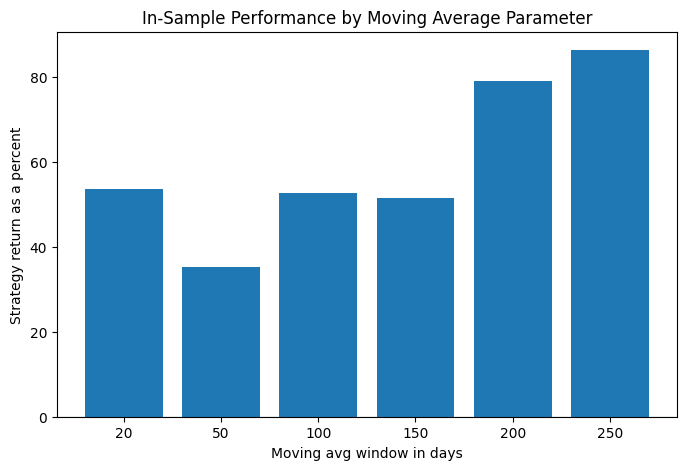

In [55]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    train_results_df["MA"].astype(str),
    train_results_df["Strategy Return"] * 100
)

plt.xlabel("Moving avg window in days")
plt.ylabel("Strategy return as a percent")
plt.title("In-Sample Performance by Moving Average Parameter")
plt.axhline(0, linewidth=0.8)

plt.show()

In [56]:
best_ma = 250

test_oos = test.copy()

test_oos["Bench_Bal"] = (
    100_000 * (1 + test_oos["Daily_Return"]).cumprod()
)

test_oos = generate_ma_signal(
    test_oos,
    ma=best_ma
)

oos_result = run_backtest(
    test_oos,
    starting_balance=100_000
)

oos_metrics = calculate_total_return(oos_result)

print(oos_metrics)

{'final_bench': np.float64(185497.56283932083), 'final_strategy': np.float64(133282.48327069916), 'bench_total_return': np.float64(0.8549756283932084), 'sys_total_return': np.float64(0.3328248327069916)}


In [57]:
print(f"250-day MA return: {oos_metrics['sys_total_return']:.2%}")
print(f"SPY buy-and-hold return: {oos_metrics['bench_total_return']:.2%}")

250-day MA return: 33.28%
SPY buy-and-hold return: 85.50%


# Part 5: Risk Analysis

In [58]:
from src.metrics import (
    calculate_total_return,
    calculate_sharpe_ratio,
    calculate_cagr,
    calculate_max_drawdown,
)

In [59]:
years = (
    (oos_result.index[-1] - oos_result.index[0]).days / 365.25
)

sharpe = calculate_sharpe_ratio(oos_result)
cagr = calculate_cagr(oos_result, years)
drawdown = calculate_max_drawdown(oos_result)

print("CAGR")
print(f"Strategy: {cagr['cagr_strategy']:.2%}")
print(f"SPY:      {cagr['cagr_bench']:.2%}")

print("\nSharpe Ratio")
print(f"Strategy: {sharpe['strategy_sharpe']:.2f}")
print(f"SPY:      {sharpe['bench_sharpe']:.2f}")

print("\nMaximum Drawdown")
print(f"Strategy: {drawdown['dd_strategy']:.2f}%")
print(f"SPY:      {drawdown['dd_bench']:.2f}%")

CAGR
Strategy: 10.08%
SPY:      23.11%

Sharpe Ratio
Strategy: 0.97
SPY:      1.43

Maximum Drawdown
Strategy: -16.28%
SPY:      -18.76%


# Part 6: OOS Robustness Test

In [60]:
ma_windows = [20, 50, 100, 150, 200, 250]

robustness_results = []

for ma in ma_windows:

    print(f"Testing OOS MA = {ma}")

    test_oos = test.copy()

    test_oos["Bench_Bal"] = (
        100_000 * (1 + test_oos["Daily_Return"]).cumprod()
    )


    test_oos = generate_ma_signal(
        test_oos,
        ma=ma
    )

    oos_result_ma = run_backtest(
        test_oos,
        starting_balance=100_000
    )

    metrics = calculate_total_return(oos_result_ma)

    robustness_results.append({
        "MA": ma,
        "OOS Strategy Return": metrics["sys_total_return"],
        "Final Strategy Balance": metrics["final_strategy"],
        "OOS Benchmark Return": metrics["bench_total_return"],
        "Final Benchmark Balance": metrics["final_bench"]
    })

robustness_df = pd.DataFrame(robustness_results)

robustness_df

Testing OOS MA = 20
Testing OOS MA = 50
Testing OOS MA = 100
Testing OOS MA = 150
Testing OOS MA = 200
Testing OOS MA = 250


,MA,OOS Strategy Return,Final Strategy Balance,OOS Benchmark Return,Final Benchmark Balance
0,20,0.349070,134906.981604,0.854976,185497.562839
1,50,0.615636,161563.636030,0.854976,185497.562839
2,100,0.599273,159927.280577,0.854976,185497.562839
3,150,0.476668,147666.828486,0.854976,185497.562839
4,200,0.529791,152979.097014,0.854976,185497.562839
5,250,0.332825,133282.483271,0.854976,185497.562839


# Part 7: Transaction Costs & Slippage

In [62]:
cost_test = test.copy()

cost_test = generate_ma_signal(
    cost_test,
    ma=250
)

trades = cost_test["Long"].diff().abs().sum()

print(f"Number of trades: {int(trades)}")

Number of trades: 11


In [66]:
transaction_cost = 0.001  # 0.10% per trade

cost_result = cost_result.copy()

cost_result["Trade"] = cost_result["Long"].diff().abs()

cost_result["Net_Ret"] = (
    cost_result["Sys_Ret"]
    * (1 - cost_result["Trade"] * transaction_cost)
)

cost_result["Gross_Bal"] = (
    100_000 * cost_result["Sys_Ret"].cumprod()
)

cost_result["Net_Bal"] = (
    100_000 * cost_result["Net_Ret"].cumprod()
)

final_gross = cost_result["Gross_Bal"].iloc[-1]
final_net = cost_result["Net_Bal"].iloc[-1]

gross_return = final_gross / 100_000 - 1
net_return = final_net / 100_000 - 1

print(f"Number of trades: {int(cost_result['Trade'].sum())}")
print(f"Gross return:     {gross_return:.2%}")
print(f"Net return:       {net_return:.2%}")
print(f"Transaction cost impact: {(gross_return - net_return):.2%}")

Number of trades: 11
Gross return:     33.28%
Net return:       31.82%
Transaction cost impact: 1.46%


In [67]:
transaction_costs = [0.000, 0.0005, 0.001, 0.0025, 0.005]

cost_sensitivity = []

for cost in transaction_costs:

    sensitivity_result = cost_result.copy()

    # Apply transaction cost
    sensitivity_result["Sensitivity_Net_Ret"] = (
        sensitivity_result["Sys_Ret"]
        * (1 - sensitivity_result["Trade"] * cost)
    )

    final_balance = (
        100_000
        * sensitivity_result["Sensitivity_Net_Ret"].cumprod()
    )

    net_return = final_balance.iloc[-1] / 100_000 - 1

    cost_sensitivity.append({
        "Transaction Cost": cost,
        "Net OOS Return": net_return
    })

cost_sensitivity_df = pd.DataFrame(cost_sensitivity)

cost_sensitivity_df["Transaction Cost"] = (
    cost_sensitivity_df["Transaction Cost"] * 100
)

cost_sensitivity_df["Net OOS Return"] = (
    cost_sensitivity_df["Net OOS Return"] * 100
)

cost_sensitivity_df

,Transaction Cost,Net OOS Return
0,0.00,33.282483
1,0.05,32.551260
2,0.10,31.823685
3,0.25,29.662689
4,0.50,26.132488


# Part 8: Market Regime Analysis

In [69]:
regime_data = price.copy()

regime_data["SPY_MA200"] = (
    regime_data["Close"]
    .rolling(200)
    .mean()
)

regime_data = regime_data.loc[
    "2023-01-01":"2025-12-31"
].copy()

regime_data["Regime"] = np.where(
    regime_data["Close"] > regime_data["SPY_MA200"],
    "Bull",
    "Bear"
)

print(regime_data["Regime"].value_counts())

Regime
Bull    694
Bear     58
Name: count, dtype: int64


In [70]:
strategy_data = test.copy()

strategy_data = generate_ma_signal(
    strategy_data,
    ma=250
)

strategy_data = run_backtest(
    strategy_data,
    starting_balance=100_000
)

strategy_data["SPY_MA200"] = regime_data["SPY_MA200"]
strategy_data["Regime"] = regime_data["Regime"]

regime_returns = (
    strategy_data
    .groupby("Regime")
    .agg(
        Strategy_Daily_Return=("Sys_Ret", lambda x: (x - 1).mean()),
        SPY_Daily_Return=("Daily_Return", "mean"),
        Days=("Sys_Ret", "count")
    )
)

regime_returns

,Strategy_Daily_Return,SPY_Daily_Return,Days
Regime,,,
Bear,-0.002298,-0.001062,58
Bull,0.000630,0.001030,694


In [71]:
regime_performance = []

for regime in ["Bull", "Bear"]:

    regime_df = strategy_data[
        strategy_data["Regime"] == regime
    ].copy()

    strategy_return = (
        regime_df["Sys_Ret"].prod() - 1
    )

    spy_return = (
        (1 + regime_df["Daily_Return"]).prod() - 1
    )

    regime_performance.append({
        "Regime": regime,
        "Strategy Return": strategy_return,
        "SPY Return": spy_return,
        "Days": len(regime_df)
    })

regime_performance_df = pd.DataFrame(
    regime_performance
)

regime_performance_df

,Regime,Strategy Return,SPY Return,Days
0,Bull,0.526267,0.998906,694
1,Bear,-0.126742,-0.072005,58


In [72]:
drawdown_by_regime = []

for regime in ["Bull", "Bear"]:

    regime_df = strategy_data[
        strategy_data["Regime"] == regime
    ].copy()

    strategy_equity = regime_df["Sys_Ret"].cumprod()

    spy_equity = (1 + regime_df["Daily_Return"]).cumprod()

    strategy_dd = (
        strategy_equity / strategy_equity.cummax() - 1
    ).min()

    spy_dd = (
        spy_equity / spy_equity.cummax() - 1
    ).min()

    drawdown_by_regime.append({
        "Regime": regime,
        "Strategy Max Drawdown": strategy_dd,
        "SPY Max Drawdown": spy_dd
    })

drawdown_regime_df = pd.DataFrame(
    drawdown_by_regime
)

drawdown_regime_df

,Regime,Strategy Max Drawdown,SPY Max Drawdown
0,Bull,-0.084056,-0.084056
1,Bear,-0.126742,-0.200628
